# Employee Data Analysis
## Overview
This project demonstrates a complete data analysis workflow:
1. **Load & Explore** - Understand the raw data
2. **Clean** - Fix missing values, duplicates, formatting
4. **Visualize** - Create professional charts

**Dataset**: Messy Employee Dataset (1000+ employee records) taken from kaggle.

---

##Importing Libraries

We'll use three main libraries:
- **Pandas**: Data manipulation and cleaning
- **NumPy**: Numerical operations and statistics
- **Matplotlib**: Data visualization

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("✓ Libraries imported successfully!")

✓ Libraries imported successfully!


##Loading the Data

Upload your CSV file to Google Colab and load it into a DataFrame.

In [41]:
from google.colab import files

print("Please upload your file:")
uploaded = files.upload()

# Get the filename
filename = list(uploaded.keys())[0]

# Load the CSV file
df = pd.read_csv(filename)

print(f"✓ Data loaded! Shape: {df.shape}")
print(f"  Rows: {df.shape[0]}, Columns: {df.shape[1]}")


Please upload your file:


Saving Messy_Employee_dataset.csv to Messy_Employee_dataset (1).csv
✓ Data loaded! Shape: (1020, 12)
  Rows: 1020, Columns: 12


##Explore the Raw Data

Before cleaning, let's understand what we're working with.

In [42]:
# Display first few rows
print("=" * 80)
print("FIRST 5 ROWS OF DATA:")
print("=" * 80)
print(df.head())

print("\n" + "=" * 80)
print("DATA INFO - Column Names & Types:")
print("=" * 80)
print(df.info())

# Check data types
print("\n" + "=" * 80)
print("DATA TYPES:")
print("=" * 80)
print(df.dtypes)

print("\n" + "=" * 80)
print("BASIC STATISTICS:")
print("=" * 80)
print(df.describe())

FIRST 5 ROWS OF DATA:
  Employee_ID First_Name Last_Name   Age   Department_Region    Status  \
0     EMP1000        Bob     Davis  25.0   DevOps-California    Active   
1     EMP1001        Bob     Brown   NaN       Finance-Texas    Active   
2     EMP1002      Alice     Jones   NaN        Admin-Nevada   Pending   
3     EMP1003        Eva     Davis  25.0        Admin-Nevada  Inactive   
4     EMP1004      Frank  Williams  25.0  Cloud Tech-Florida    Active   

    Join_Date     Salary                       Email       Phone  \
0    4/2/2021   59767.65       bob.davis@example.com -1651623197   
1   7/10/2020   65304.66       bob.brown@example.com -1898471390   
2   12/7/2023   88145.90     alice.jones@example.com -5596363211   
3  11/27/2021   69450.99       eva.davis@example.com -3476490784   
4    1/5/2022  109324.61  frank.williams@example.com -1586734256   

  Performance_Score  Remote_Work  
0           Average         True  
1         Excellent         True  
2              Good

##Identify Data Quality Issues

Let's check for the problems we need to fix.

In [43]:
# Check for missing values
print("=" * 80)
print("MISSING VALUES:")
print("=" * 80)
missing = df.isnull().sum()                     # df.isnull() method
missing_pct = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Column': missing.index,
    'Missing_Count': missing.values,
    'Missing_Percentage': missing_pct.values
})

print(missing_df[missing_df['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False))

# Check for duplicates
print("\n" + "=" * 80)
print("DUPLICATE ROWS:")
print("=" * 80)
duplicates = df.duplicated().sum()           # duplicated() method
print(f"Total duplicate rows: {duplicates}")



MISSING VALUES:
   Column  Missing_Count  Missing_Percentage
3     Age            211           20.686275
7  Salary             24            2.352941

DUPLICATE ROWS:
Total duplicate rows: 0


## Cleaning the Data

Now we'll fix all the issues we found.

In [44]:
df_clean = df.copy() # Create a copy for cleaning
print("Starting data cleaning...\n")

# 1. Remove duplicate rows
print("Step 1: Removing duplicate rows...")
print(f"  ✓ No duplicate rows to remove")

# 2. Handle missing values in different columns
print("\nStep 2: Handling missing values...")
df_clean = df_clean.fillna(df_clean.mean(numeric_only=True))      #fillna()
df_clean = df_clean.fillna("Unknown")
print("  ✓ Filled missing values")

# 3. Fix specific columns if they exist
print("\nStep 4: Fixing specific column issues...")

# Split Department_Region column
if 'Department_Region' in df_clean.columns:
    df_clean[['Department', 'Region']] = df_clean['Department_Region'].str.split('-', expand=True)
    df_clean = df_clean.drop('Department_Region', axis=1)
    print("  ✓ Split Department_Region")

# Convert Salary to numbers
if 'Salary' in df_clean.columns:
    df_clean['Salary'] = pd.to_numeric(df_clean['Salary'], errors='coerce')    #to_numeric()
    print("  ✓ Converted Salary to numeric")

# 4. Standardize text columns
print("\nStep 2: Standardizing text columns...")
for col in df_clean.select_dtypes(include=['object']).columns:        #df.select_dtypes(include=['object'])
    df_clean[col] = df_clean[col].str.strip().str.title()
print("  ✓ Standardized all text columns")

# 5. Remove rows with critical missing values (after filling)
print("\nStep 5: Final quality checks...")
initial_rows_check = len(df_clean)
df_clean = df_clean.dropna()
print(f"  ✓ Removed rows with remaining missing values: {initial_rows_check - len(df_clean)} rows")

print("\n" + "=" * 80)
print("DATA CLEANING COMPLETE!")
print("=" * 80)
print(f"Original dataset: {df.shape[0]} rows")
print(f"Cleaned dataset: {df_clean.shape[0]} rows")
print(f"Rows removed: {df.shape[0] - df_clean.shape[0]}")

Starting data cleaning...

Step 1: Removing duplicate rows...
  ✓ No duplicate rows to remove

Step 2: Handling missing values...
  ✓ Filled missing values

Step 4: Fixing specific column issues...
  ✓ Split Department_Region
  ✓ Converted Salary to numeric

Step 2: Standardizing text columns...
  ✓ Standardized all text columns

Step 5: Final quality checks...
  ✓ Removed rows with remaining missing values: 0 rows

DATA CLEANING COMPLETE!
Original dataset: 1020 rows
Cleaned dataset: 1020 rows
Rows removed: 0


##Verify Cleaned Data

Let's confirm the data is now clean and ready for analysis.

In [45]:
print("=" * 80)
print("CLEANED DATA PREVIEW:")
print("=" * 80)
print(df_clean.head())

print("\n" + "=" * 80)
print("CLEANED DATA INFO:")
print("=" * 80)
print(df_clean.info())

print("\n" + "=" * 80)
print("MISSING VALUES CHECK:")
print("=" * 80)
missing_after = df_clean.isnull().sum()
if missing_after.sum() == 0:
    print("✓ No missing values! Data is clean.")
else:
    print(missing_after[missing_after > 0])

CLEANED DATA PREVIEW:
  Employee_ID First_Name Last_Name        Age    Status   Join_Date  \
0     Emp1000        Bob     Davis  25.000000    Active    4/2/2021   
1     Emp1001        Bob     Brown  32.484549    Active   7/10/2020   
2     Emp1002      Alice     Jones  32.484549   Pending   12/7/2023   
3     Emp1003        Eva     Davis  25.000000  Inactive  11/27/2021   
4     Emp1004      Frank  Williams  25.000000    Active    1/5/2022   

      Salary                       Email       Phone Performance_Score  \
0   59767.65       Bob.Davis@Example.Com -1651623197           Average   
1   65304.66       Bob.Brown@Example.Com -1898471390         Excellent   
2   88145.90     Alice.Jones@Example.Com -5596363211              Good   
3   69450.99       Eva.Davis@Example.Com -3476490784              Good   
4  109324.61  Frank.Williams@Example.Com -1586734256              Poor   

   Remote_Work  Department      Region  
0         True      Devops  California  
1         True     Finan

##Exploratory Data Analysis (EDA) or Exploring Data

Now let's understand the patterns and trends in the data.

In [46]:
print("=" * 80)
print("DESCRIPTIVE STATISTICS:")
print("=" * 80)
print(df_clean.describe())

print("\n" + "=" * 80)
print("KEY INSIGHTS FROM DATA:")
print("=" * 80)

# Numerical columns analysis
numerical_cols_clean = df_clean.select_dtypes(include=[np.number]).columns  #select columns with specific data type
for col in numerical_cols_clean:
    print(f"\n{col}:")
    print(f"  Mean: {df_clean[col].mean():.2f}")
    print(f"  Median: {df_clean[col].median():.2f}")
    print(f"  Std Dev: {df_clean[col].std():.2f}")
    print(f"  Min: {df_clean[col].min():.2f}")
    print(f"  Max: {df_clean[col].max():.2f}")

DESCRIPTIVE STATISTICS:
               Age         Salary         Phone
count  1020.000000    1020.000000  1.020000e+03
mean     32.484549   85155.056396 -4.942253e+09
std       5.037256   19638.295389  2.817326e+09
min      25.000000   50047.320000 -9.994973e+09
25%      30.000000   68811.232500 -7.341992e+09
50%      32.484549   85155.056396 -4.943997e+09
75%      35.000000  100372.662500 -2.520391e+09
max      40.000000  119971.650000 -3.896086e+06

KEY INSIGHTS FROM DATA:

Age:
  Mean: 32.48
  Median: 32.48
  Std Dev: 5.04
  Min: 25.00
  Max: 40.00

Salary:
  Mean: 85155.06
  Median: 85155.06
  Std Dev: 19638.30
  Min: 50047.32
  Max: 119971.65

Phone:
  Mean: -4942252959.22
  Median: -4943996508.50
  Std Dev: 2817326049.74
  Min: -9994973202.00
  Max: -3896086.00


## Categorical Analysis

Analyze categorical columns to find distributions and patterns.

In [47]:
categorical_cols_clean = df_clean.select_dtypes(include=['object']).columns

print("=" * 80)
print("CATEGORICAL DATA DISTRIBUTION:")
print("=" * 80)

for col in categorical_cols_clean:
    print(f"\n{col} - Value Counts:")
    print(df_clean[col].value_counts().head())
    print(f"  Total unique values: {df_clean[col].nunique()}")  #nunique method

CATEGORICAL DATA DISTRIBUTION:

Employee_ID - Value Counts:
Employee_ID
Emp2019    1
Emp1000    1
Emp1001    1
Emp1002    1
Emp1003    1
Name: count, dtype: int64
  Total unique values: 1020

First_Name - Value Counts:
First_Name
Frank      142
Grace      140
Eva        136
Bob        133
Charlie    125
Name: count, dtype: int64
  Total unique values: 8

Last_Name - Value Counts:
Last_Name
Brown     148
Garcia    136
Smith     136
Jones     131
Davis     120
Name: count, dtype: int64
  Total unique values: 8

Status - Value Counts:
Status
Pending     356
Active      352
Inactive    312
Name: count, dtype: int64
  Total unique values: 3

Join_Date - Value Counts:
Join_Date
6/10/2024    5
6/5/2024     4
11/7/2021    4
12/7/2023    4
8/21/2023    4
Name: count, dtype: int64
  Total unique values: 760

Email - Value Counts:
Email
Grace.Brown@Example.Com      27
Frank.Smith@Example.Com      25
Grace.Smith@Example.Com      23
Charlie.Jones@Example.Com    22
Frank.Brown@Example.Com      22
Na

In [48]:
print("=" * 80)
print("CORRELATION ANALYSIS:")
print("=" * 80)

# Calculate correlations for numerical columns
numerical_cols_list = df_clean.select_dtypes(include=[np.number]).columns.tolist()
if len(numerical_cols_list) > 1:
    correlation_matrix = df_clean[numerical_cols_list].corr()
    print("\nCorrelation Matrix:")
    print(correlation_matrix)
    print("\nInterpretation: Values close to 1 indicate strong positive correlation")
    print("Values close to -1 indicate strong negative correlation")
else:
    print("Not enough numerical columns for correlation analysis")

# Group by analysis
print("\n" + "=" * 80)
print("GROUP-BY ANALYSIS:")
print("=" * 80)

# Example: Group by Department and show average salary
if 'Department' in df_clean.columns and 'Salary' in df_clean.columns:
    dept_salary = df_clean.groupby('Department')['Salary'].agg(['mean', 'median', 'count'])
    dept_salary.columns = ['Avg_Salary', 'Median_Salary', 'Employee_Count']
    print("\nAverage Salary by Department:")
    print(dept_salary.sort_values('Avg_Salary', ascending=False))

# Group by Status
if 'Status' in df_clean.columns:
    status_count = df_clean['Status'].value_counts()
    print("\nEmployee Status Distribution:")
    print(status_count)
    print(f"\nPercentages:")
    print((status_count / len(df_clean) * 100).round(2))

CORRELATION ANALYSIS:

Correlation Matrix:
             Age    Salary     Phone
Age     1.000000  0.080476  0.041748
Salary  0.080476  1.000000 -0.057473
Phone   0.041748 -0.057473  1.000000

Interpretation: Values close to 1 indicate strong positive correlation
Values close to -1 indicate strong negative correlation

GROUP-BY ANALYSIS:

Average Salary by Department:
              Avg_Salary  Median_Salary  Employee_Count
Department                                             
Sales       86867.327804   86453.775000             178
Devops      85993.246730   85155.056396             189
Hr          85466.190851   85155.056396             171
Admin       85190.812361   86383.915000             166
Cloud Tech  84930.982137   85155.056396             146
Finance     82274.898016   83809.195000             170

Employee Status Distribution:
Status
Pending     356
Active      352
Inactive    312
Name: count, dtype: int64

Percentages:
Status
Pending     34.90
Active      34.51
Inactive    3

##Data Visualization - Chart 1: Salary Distribution

Visualize the distribution of employee salaries using a histogram.

/tmp/ipykernel_14971/2190592509.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=10)


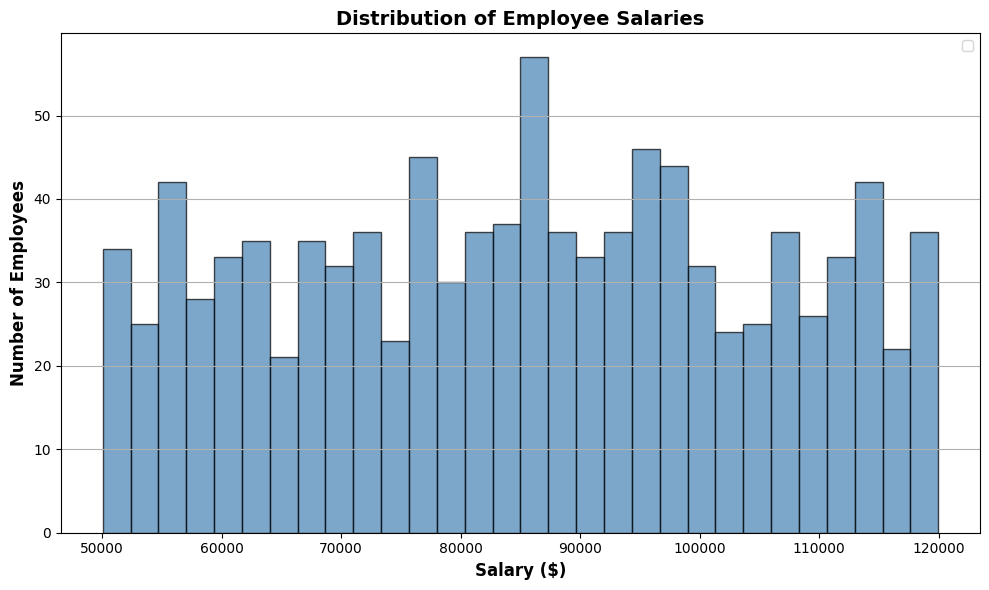


Key Insights:
  • Average Salary: $85,155.06
  • Median Salary: $85,155.06
  • Salary Range: $50,047.32 - $119,971.65


In [49]:
if 'Salary' in df_clean.columns:
    plt.figure(figsize=(10, 6))
    plt.hist(df_clean['Salary'], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
    plt.xlabel('Salary ($)', fontsize=12, fontweight='bold')
    plt.ylabel('Number of Employees', fontsize=12, fontweight='bold')
    plt.title('Distribution of Employee Salaries', fontsize=14, fontweight='bold')
    plt.grid(axis='y')

    mean_salary = df_clean['Salary'].mean()
    median_salary = df_clean['Salary'].median()

    plt.legend(fontsize=10)
    plt.tight_layout()
    plt.show()

    print(f"\nKey Insights:")
    print(f"  • Average Salary: ${mean_salary:,.2f}")
    print(f"  • Median Salary: ${median_salary:,.2f}")
    print(f"  • Salary Range: ${df_clean['Salary'].min():,.2f} - ${df_clean['Salary'].max():,.2f}")
else:
    print("Salary column not found in dataset")

##Data Visualization - Chart 2: Department-wise Analysis

Compare employee counts and salaries across departments.

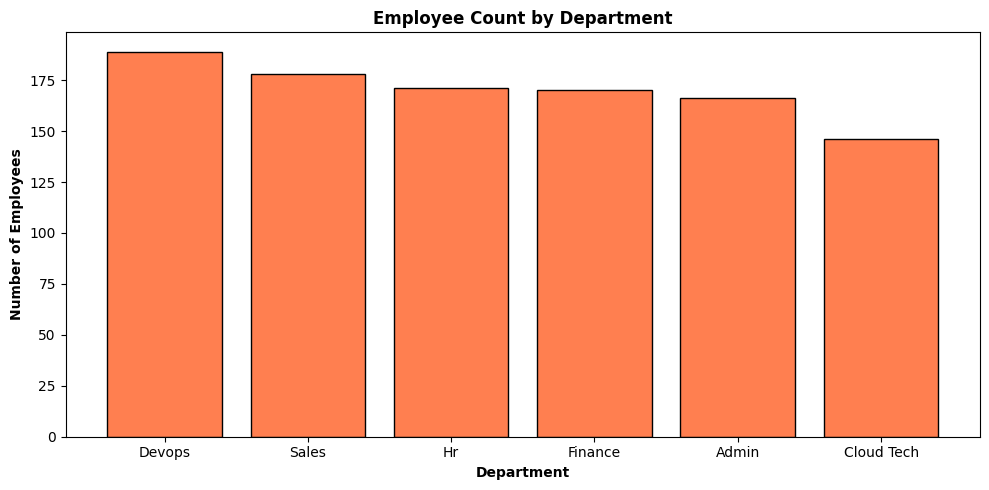

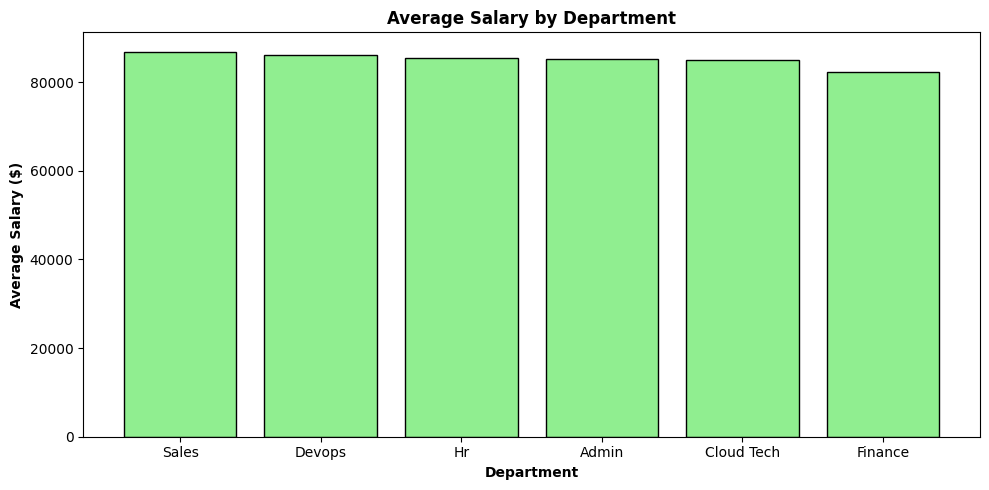


Total Departments: 6

Employee Distribution:
Department
Devops        189
Sales         178
Hr            171
Finance       170
Admin         166
Cloud Tech    146
Name: count, dtype: int64


In [50]:
if 'Department' in df_clean.columns:
    # Chart 1: Employee count by department
    plt.figure(figsize=(10, 5))
    dept_counts = df_clean['Department'].value_counts()
    plt.bar(dept_counts.index, dept_counts.values, color='coral', edgecolor='black')
    plt.xlabel('Department', fontweight='bold')
    plt.ylabel('Number of Employees', fontweight='bold')
    plt.title('Employee Count by Department', fontweight='bold')
    plt.tight_layout()
    plt.show()

    # Chart 2: Average salary by department
    if 'Salary' in df_clean.columns:
        plt.figure(figsize=(10, 5))
        dept_avg_salary = df_clean.groupby('Department')['Salary'].mean().sort_values(ascending=False)
        plt.bar(dept_avg_salary.index, dept_avg_salary.values, color='lightgreen', edgecolor='black')
        plt.xlabel('Department', fontweight='bold')
        plt.ylabel('Average Salary ($)', fontweight='bold')
        plt.title('Average Salary by Department', fontweight='bold')
        plt.tight_layout()
        plt.show()

    print(f"\nTotal Departments: {df_clean['Department'].nunique()}")
    print(f"\nEmployee Distribution:")
    print(dept_counts)
else:
    print("Department column not found")

##Data Visualization - Chart 4: Performance Rating Analysis

Visualize performance scores if available.

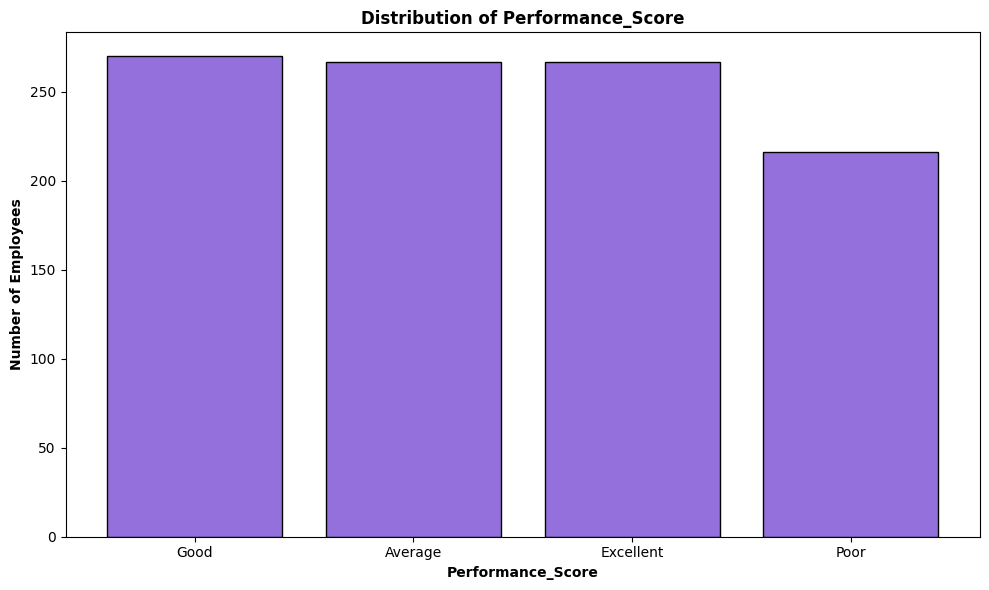


Performance_Score Distribution:
Performance_Score
Good         270
Average      267
Excellent    267
Poor         216
Name: count, dtype: int64


In [51]:
# Find performance-related columns
perf_cols = [col for col in df_clean.columns if 'performance' in col.lower() or 'rating' in col.lower() or 'score' in col.lower()]

if perf_cols:
    perf_col = perf_cols[0]

    # Count occurrences of each rating
    rating_counts = df_clean[perf_col].value_counts()

    plt.figure(figsize=(10, 6))
    plt.bar(rating_counts.index, rating_counts.values, color='mediumpurple', edgecolor='black')
    plt.xlabel(perf_col, fontweight='bold')
    plt.ylabel('Number of Employees', fontweight='bold')
    plt.title(f'Distribution of {perf_col}', fontweight='bold')
    plt.tight_layout()
    plt.show()

    print(f"\n{perf_col} Distribution:")
    print(rating_counts)
else:
    print("No performance rating column found.")

#Export Cleaned Data

Save the cleaned dataset for future use.

In [52]:
# Save the cleaned dataset
df_clean.to_csv('cleaned_employee_data.csv', index=False)
print("✓ Cleaned data exported to 'cleaned_employee_data.csv'")

# Download the cleaned file
from google.colab import files
files.download('cleaned_employee_data.csv')
print("✓ File downloaded to your computer")

✓ Cleaned data exported to 'cleaned_employee_data.csv'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ File downloaded to your computer
